<a href="https://colab.research.google.com/github/IvanCortesGit-Hub/BasicWebSite-Static-/blob/develop/ClusteringK_MeanstoBD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
# Parte 1: Cargar datos y librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Cargar dataset
df = pd.read_csv("/content/winequality-white.csv", sep=";")  # En colab cambia la ruta si es necesario

# Mostrar primeras filas
print(df.head())
print(df.shape)

# Escalar variables (K-means es sensible a magnitudes)
X = df.drop("quality", axis=1)  # Usamos solo las variables fisicoquímicas
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.0              0.27         0.36            20.7      0.045   
1            6.3              0.30         0.34             1.6      0.049   
2            8.1              0.28         0.40             6.9      0.050   
3            7.2              0.23         0.32             8.5      0.058   
4            7.2              0.23         0.32             8.5      0.058   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 45.0                 170.0   1.0010  3.00       0.45   
1                 14.0                 132.0   0.9940  3.30       0.49   
2                 30.0                  97.0   0.9951  3.26       0.44   
3                 47.0                 186.0   0.9956  3.19       0.40   
4                 47.0                 186.0   0.9956  3.19       0.40   

   alcohol  quality  
0      8.8        6  
1      9.5        6  
2     10.1        6 

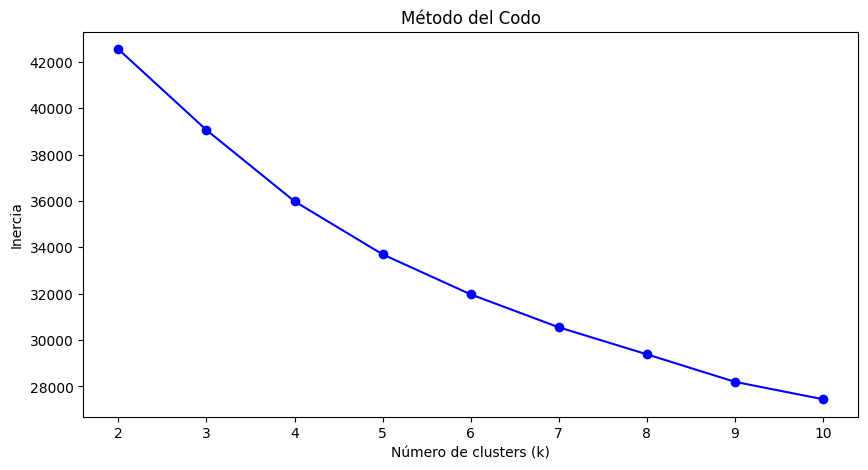

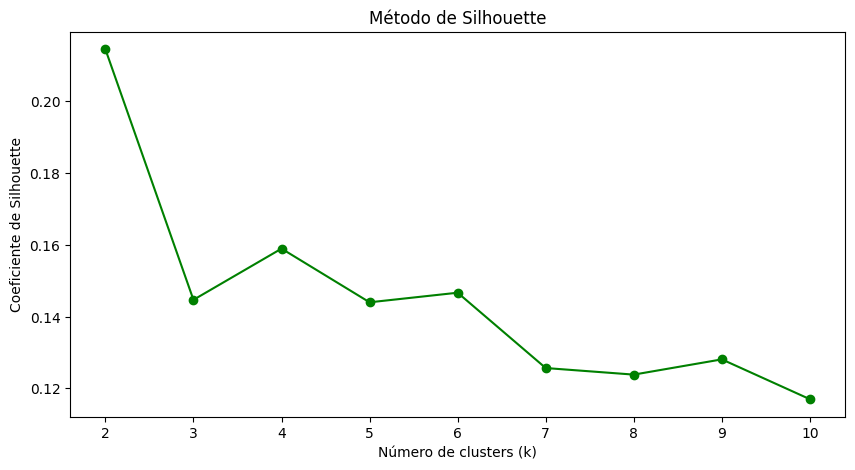

In [44]:
# Parte 3: Selección del número de clusters
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia = []
silhouette = []
K = range(2,11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(X_scaled, kmeans.labels_))

# Gráfico del método del codo
plt.figure(figsize=(10,5))
plt.plot(K, inertia, 'o-', color='blue')
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.title("Método del Codo")
plt.show()

# Gráfico de silhouette
plt.figure(figsize=(10,5))
plt.plot(K, silhouette, 'o-', color='green')
plt.xlabel("Número de clusters (k)")
plt.ylabel("Coeficiente de Silhouette")
plt.title("Método de Silhouette")
plt.show()


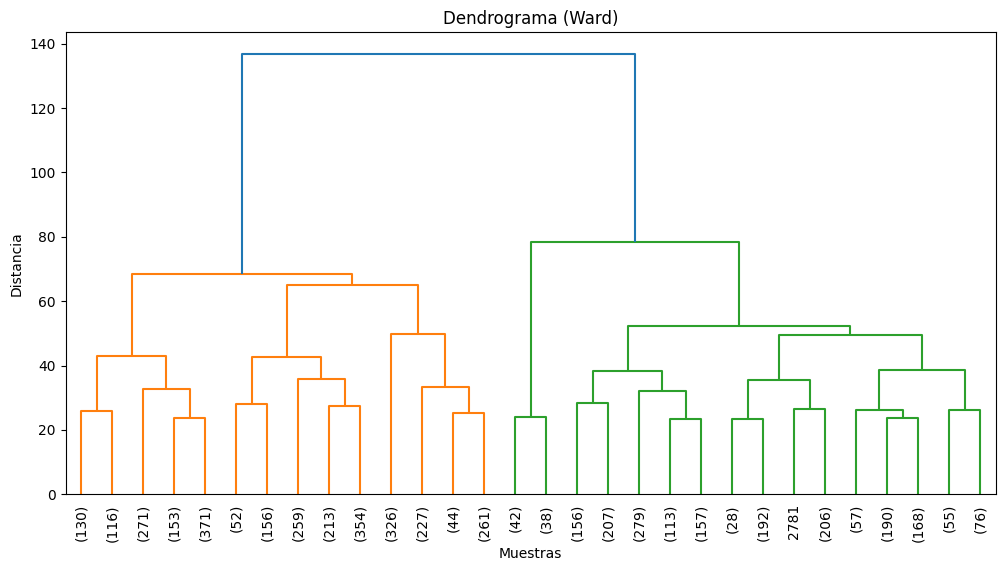

In [53]:
# Parte 4: Dendrograma
""" AUNQUE K-MEANS NO POSEE DENDOGRAMA COMO METODO PARA DEFINIR LA CANTIDAD DE CLUSTERS, YA QUE EL DENDOGRAMA SE ENFOCA EN JERARQUICO...
    DECIDO REALIZARLO, PARA VER UNA GRAFICA ADICIONAL QUE DEMUESTRA QUE CLUSTERS =2 ES LA MEJOR ELECCION, AUNQUE VEREMOS QUE...
    EL COEFICIENTE DE SILHOUTTE ES DE 0.21, NO MUY EFECTIVO. PERO MEJOR QUE JERARQUICO Y QUE DBSCAN
"""
from scipy.cluster.hierarchy import dendrogram, linkage

plt.figure(figsize=(12,6))
linked = linkage(X_scaled, method='ward')
dendrogram(linked, truncate_mode='lastp', p=30, leaf_rotation=90., leaf_font_size=10.)
plt.title("Dendrograma (Ward)")
plt.xlabel("Muestras")
plt.ylabel("Distancia")
plt.show()


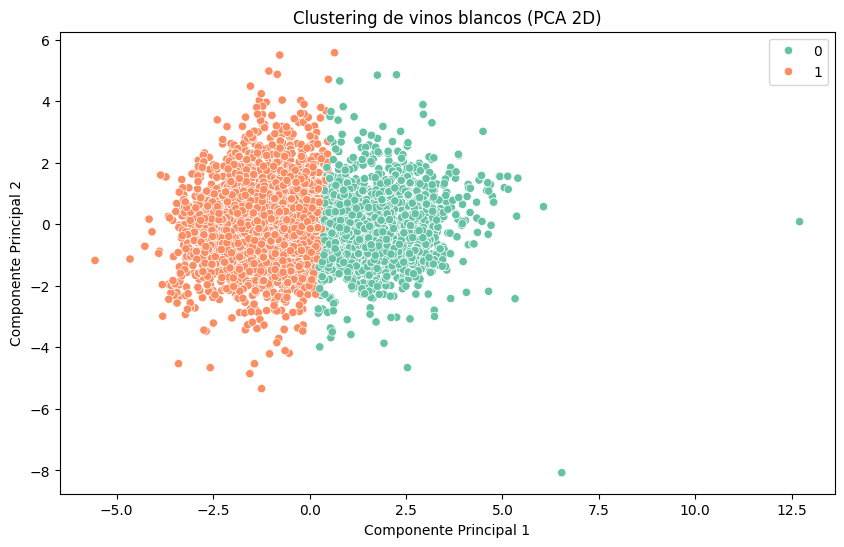

Coeficiente de Silhouette del modelo final: 0.214


In [47]:
# Parte 5: Modelo final con el k elegido (ejemplo k=2)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

# Visualización PCA 2D
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

plt.figure(figsize=(10,6))
sns.scatterplot(x=pca_result[:,0], y=pca_result[:,1], hue=clusters, palette="Set2")
plt.title("Clustering de vinos blancos (PCA 2D)")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.show()

# Precisión del modelo usando Silhouette
score = silhouette_score(X_scaled, clusters)
print(f"Coeficiente de Silhouette del modelo final: {score:.3f}")


In [49]:
sil_score = silhouette_score(X_scaled, clusters)
print(f"Coeficiente de Silhouette (jerárquico): {sil_score:.3f}")


Coeficiente de Silhouette (jerárquico): 0.214
